This script is to construct a simple 2D underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. 

In [2]:
import os
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import scipy.stats as stats
import subprocess
import os
from pathlib import Path
import math

In [3]:
import generate_random_field  
import Mesh_settings  

In the first step, we make some settings. 

To create a mesh, we set the size and number of cells of the mesh.

To assign a ground property (e.g. stiffness) to all the nodes of the mesh, we give the mean and variance for each layer.

If the parameter has a linear relationship with depth, we set the slope. 

To generate a random field, we set the scale of fluctuation. Random seed is to initiate a random field. Same seed can reproduce the same random field.

In [5]:
# import parameters from mesh_settings configuration file

filename = Mesh_settings.filename
width_of_boundary = Mesh_settings.width_of_boundary
depth_of_boundary = Mesh_settings.depth_of_boundary
number_of_cells_x = Mesh_settings.number_of_cells_x
number_of_cells_y = Mesh_settings.number_of_cells_y
number_of_layers = Mesh_settings.number_of_layers

stiffness_mean = Mesh_settings.stiffness_mean  # Pa 
variance = Mesh_settings.variance   # for making random field
slope = Mesh_settings.slope

horizontal_scale_of_fluctuation = Mesh_settings.horizontal_scale_of_fluctuation
vertical_scale_of_fluctuation = Mesh_settings.vertical_scale_of_fluctuation

We create a output directory. All generated files will be put there.

In [7]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)

In [54]:
os.chdir(out_dir)
file = filename + '.vtu'

We make a mesh by running the command line by subprocess.

In [10]:
subprocess.run("generateStructuredMesh -e quad -o "  + file + " --lx " + str(width_of_boundary) + " --ly " + str(depth_of_boundary) 
               + " --nx " + str(number_of_cells_x) + " --ny " + str(number_of_cells_y) + " --oy " + str( - depth_of_boundary)  ) 

CompletedProcess(args='generateStructuredMesh -e quad -o domain.vtu --lx 10 --ly 60 --nx 10 --ny 60 --oy -60', returncode=0)

In [11]:
subprocess.run("identifySubdomains -m " + file  + " -s 1e-6 -f " + file)

CompletedProcess(args='identifySubdomains -m domain.vtu -s 1e-6 -f domain.vtu', returncode=0)

In [12]:
# pyvista settings

pv.set_plot_theme("document")
pv.set_jupyter_backend("static")

def show_mesh(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.view_xy()
    plotter.add_axes()
    plotter.show_bounds(mesh, xtitle="x", ytitle="y")
    plotter.window_size = [400, 1200]
    plotter.show()

def show_mesh_3D(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.add_axes()
    plotter.window_size = [800, 400]
    plotter.show()

Here we read the mesh file.

In [14]:
mesh = pv.read(file) # file
reader = vtk.vtkXMLUnstructuredGridReader()
reader.SetFileName(file) # file
reader.Update()  # Needed because of GetScalarRange
reader_data = reader.GetOutput()

We create a virtual stiffness parameter. 
For the case of constant layer, we just give a value, and repeat the number to all thcellser

For the case of depth linear dependent layer, we get mean to the cell at the middle 10). By using formulae, y=mc+x, i.e. stiffness = stiffness mean + slope factor * number of vertical cells, we can calculate stiffness at ecell.ted


In [16]:
repeat_number = int((width_of_boundary) * number_of_cells_y) 
depth_of_layer =  depth_of_boundary / number_of_layers

def constant_layer(m, r, hn, vcpl):
    layer = np.repeat(m, r).reshape(hn, vcpl)
    return layer

def depth_linear_dependent_layer (slope, m, hn, dl, vcpl):
    x = np.arange(-vcpl/2, vcpl/2)
    delta = slope * (dl / vcpl)
    y = (m + x * delta)
    layer = np.repeat (y, hn).reshape(hn, vcpl, order='F')
    return layer

stiffness= depth_linear_dependent_layer(slope, stiffness_mean[0], number_of_cells_x, depth_of_layer, number_of_cells_y)

Here we import our random field.

In [18]:
total_rf = generate_random_field.stiff_field

We combine the ground property (trend) with random field.

In [20]:
stiffness_with_RF = np.add(stiffness, total_rf)

In [21]:
# Plot variogram

#ax= stiff_model.plot("variogram")
#stiff_model.plot("covariance",ax=ax)
#stiff_model.plot("correlation", ax=ax)

We add the above result into the mesh structure, and write a new mesh file.

In [23]:
# Add parameter to vtu
stiffness_1D_array =  stiffness_with_RF.flatten('F')
stiffness_node = numpy_to_vtk(stiffness_1D_array)
stiffness_node.SetName('Stiffness')
reader_data.GetCellData().AddArray(stiffness_node)
#reader_data.GetPointData().AddArray(stiffness_node)

vtu_with_stiffness =  filename + "_with_stiffness.vtu"

writer = vtk.vtkXMLUnstructuredGridWriter()
writer.SetInputData(reader_data)
writer.SetFileName(vtu_with_stiffness)
writer.Write()

1

In [24]:
print(os.getcwd())

C:\Users\glori\Documents\tasks\ogs_exercise\_out


We read and plot the new mesh file. 

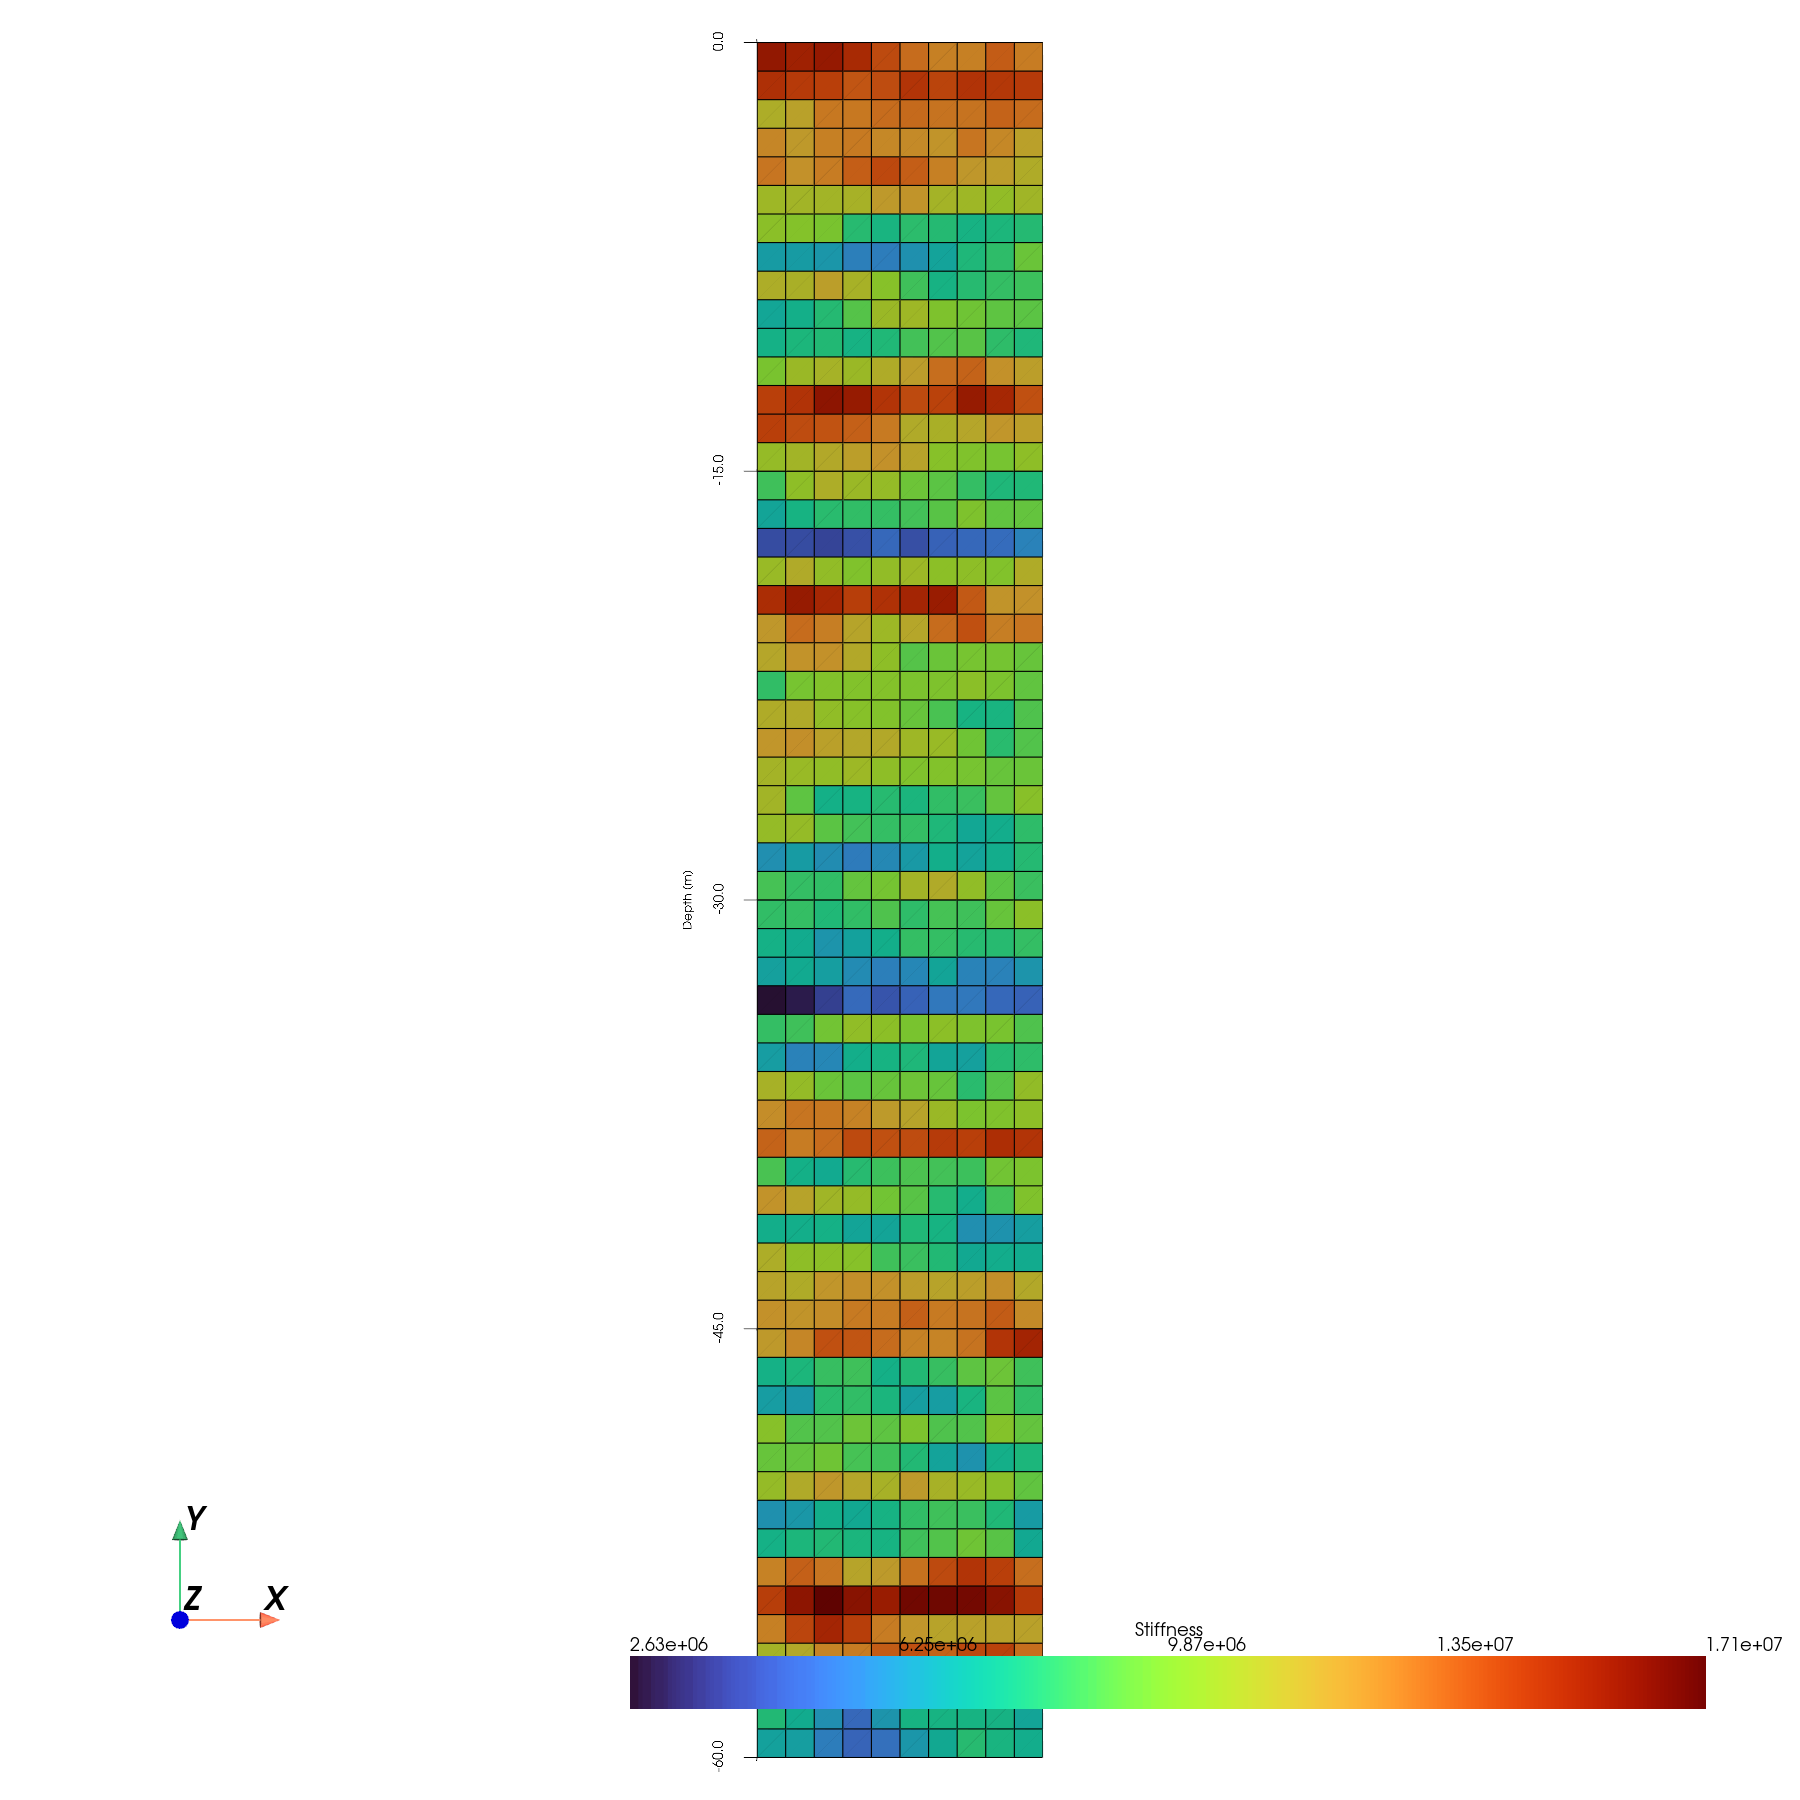

In [56]:
new_mesh = pv.read(vtu_with_stiffness)

pl = pv.Plotter()

pl.add_mesh(new_mesh,  scalars = "Stiffness", show_edges=True, cmap="turbo")
pl.view_xy()
pl.add_axes()
pl.window_size = [1800, 1800]

pl.show_grid(ytitle='Depth (m)', show_xaxis = False, show_xlabels =False, font_family ='arial', font_size=10, bold=False)

pl.show()

Here we draw a graph to visualize the change of stiffness parameter over depth. 

[ 6423036.75821855  7614155.57935783  4488155.61463073 13911846.95213499
 12056127.69344945 16693052.65504686 13128074.55093263  8610798.36615984
  8309237.59713211 11884349.78119322  7982551.29768845  9807987.05485503
  6738331.75317121  7992051.51670443 12664462.48262803 13512579.63123718
 11817326.48210276  8476635.94804425  7933505.43444692  9052545.64818549
  8837241.4432341  14027426.39333929 11595649.36953401  9452543.64028364
  7875760.47780491  9723808.92449118  4893186.19885859  6002726.89100976
  8391172.55066356  8229676.22078125 10849692.56792949  6553083.29382393
  8341786.72756324  7755989.43898693  9888130.23277259 10771612.39838479
  9319071.66694299  9785950.46383637  8973932.53337953 11458273.87084195
 15285916.7794411  10701221.71090709  4343740.7271195   8679986.57880236
  9458567.04679742 11616120.31905976 11305588.22716999 14075892.73132051
 11845828.8427415   8634766.14048423 10743270.58871234  8585680.5349977
  6258501.97435398  8209405.02532692 12129827.515594

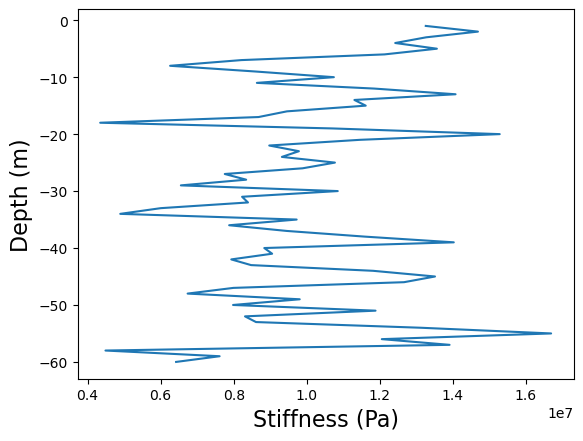

In [28]:
import matplotlib.pyplot as plt
import numpy as np

mid_axis = int(number_of_cells_x / 2)

xpoints = stiffness_with_RF[mid_axis, :]
ypoints = np.arange (-depth_of_boundary, 0, 1)

plt.xlabel('Stiffness (Pa)', fontsize=16)
plt.ylabel('Depth (m)', fontsize=16)

print (xpoints)
plt.plot(xpoints, ypoints)
plt.show()

In [29]:
os.chdir("..")

In [30]:
print(os.getcwd())

C:\Users\glori\Documents\tasks\ogs_exercise
